In [1]:
import xarray as xr
import arviz as az
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from fit_trajectories import gof_trajectories
from scipy.stats import spearmanr, pearsonr

0.9442016806722688


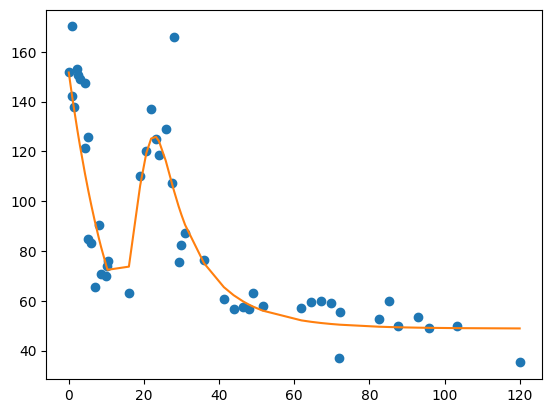

In [2]:
path = "../results/ENSDARG00000000861/numpyro_posterior.nc"
obs = xr.load_dataset(path, group="observed_data").y.mean("source")
pred = xr.load_dataset(path, group="posterior_model_fits").y.mean(dim=("draw", "chain", "source"))
rho = spearmanr(obs.values, pred.values).correlation
print(rho)

plt.plot(obs.time, obs, "o")
plt.plot(pred.time, pred)

In [3]:
idata = az.from_netcdf(path)
idata

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data
	> posterior_model_fits
	> posterior_residuals

In [7]:
def calc_BIC(idata):
    '''
    k = free parameters
    n = data points
    LL = max. Log-Likelihood (sum)
    '''

    n = len(idata.posterior_model_fits.time)
    k = len(idata.posterior.data_vars)
    LL = idata.log_likelihood.y.mean(dim=("chain", "draw")).sum().item()
    bic =  k * np.log(n) - 2 * LL
    return float(bic)

def calc_AIC(idata):
    '''
    k = free parameters
    n = data points
    LL = max. Log-Likelihood (sum)
    '''

    n = len(idata.posterior_model_fits.time)
    k = len(idata.posterior.data_vars)
    LL = idata.log_likelihood.y.mean(dim=("chain", "draw")).sum().item()
    aic = - 2 * LL + 2*k
    return float(aic)


idata = az.from_netcdf(path)
calc_BIC(idata)

-17.968965487881885

In [8]:
import numpy as np

ll = idata.log_likelihood.to_array().values  # or select var_name
print("Any NaN?", np.any(np.isnan(ll)))
print("Any Inf?", np.any(np.isinf(ll)))
print("Min/Max:", ll.min(), ll.max())
print("Per-observation variance range:", 
      ll.reshape(-1, ll.shape[-1]).var(axis=0).min(),
      ll.reshape(-1, ll.shape[-1]).var(axis=0).max())

Any NaN? False
Any Inf? False
Min/Max: -7.554338 1.1786329
Per-observation variance range: 0.08175602 0.27209792


In [9]:
import numpy as np
import xarray as xr
import arviz as az

ll = idata.log_likelihood["y"]  # dims: (chain, draw, time, source)
grouped_ll = ll.sum(dim="source")   # -> dims: (chain, draw, time)

# Wrap into a fresh InferenceData for WAIC/LOO
idata_grouped = az.InferenceData(
    posterior=idata.posterior,          # reuse original posterior
    log_likelihood=xr.Dataset({"y": grouped_ll}),
)

waic_grouped = az.waic(idata_grouped, pointwise=True, var_name="y")
loo_grouped = az.loo(idata_grouped, pointwise=True, var_name="y")

print(waic_grouped)
print(loo_grouped)

c:\Users\mgrho\anaconda3\envs\polya\Lib\site-packages\arviz\stats\stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Computed from 8000 posterior samples and 50 observations log-likelihood matrix.

          Estimate       SE
elpd_waic    18.86     6.48
p_waic        6.57        -

There has been a warning during the calculation. Please check the results.
Computed from 8000 posterior samples and 50 observations log-likelihood matrix.

         Estimate       SE
elpd_loo    18.40     6.58
p_loo        7.02        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       50  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



In [10]:
import arviz as az

k_values = loo_grouped.pareto_k.values

bad_idx = np.where(k_values > 0.7)[0]
print(f"{len(bad_idx)} bad points out of {len(k_values)}")
print("Indices:", bad_idx)

0 bad points out of 50
Indices: []


In [24]:
idata_b = az.from_netcdf("../results/ENSDARG00000000018_Basic/numpyro_posterior.nc")
idata_m = az.from_netcdf("../results/ENSDARG00000000018_Rep_M/numpyro_posterior.nc")
idata_z = az.from_netcdf("../results/ENSDARG00000000018_Rep_Z/numpyro_posterior.nc")
idata_v = az.from_netcdf("../results/ENSDARG00000000018_Rep_V/numpyro_posterior.nc")

dict = {"Basic": idata_b,
        "Rep_M": idata_m,
        "Rep_Z": idata_z,
        "Rep_V": idata_v}
dict1 = dict.copy()

for x in dict:
        idata = dict[x]
        ll = idata.log_likelihood["y"]  # dims: (chain, draw, time, source)
        grouped_ll = ll.sum(dim="source")   # -> dims: (chain, draw, time)
        idata_grouped = az.InferenceData(posterior=idata.posterior, log_likelihood=xr.Dataset({"y": grouped_ll}),)
        dict1[x] = idata_grouped
print(az.compare(dict1))

c:\Users\mgrho\anaconda3\envs\polya\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


       rank   elpd_loo     p_loo  elpd_diff        weight        se       dse  \
Rep_V     0 -13.755157  8.355798   0.000000  1.000000e+00  5.575635  0.000000   
Rep_Z     1 -14.952022  6.690565   1.196865  7.567280e-13  5.269500  0.707750   
Rep_M     2 -15.540750  6.841498   1.785593  4.121148e-13  5.309828  0.627610   
Basic     3 -50.956989  3.337950  37.201833  0.000000e+00  8.697937  7.859753   

       warning scale  
Rep_V     True   log  
Rep_Z    False   log  
Rep_M     True   log  
Basic    False   log  


c:\Users\mgrho\anaconda3\envs\polya\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [ ]:
def calc_nrmse(obs, pred):
    '''Normalized Root Mean Square Error'''
    rmse = np.sqrt(np.mean((obs - pred)**2))
    nrmse_range = rmse / (obs.max() - obs.min())
    nrmse_mean = rmse / obs.mean()
    nrmse_std = rmse / obs.std()
    return [nrmse_range.item(), nrmse_mean.item(), nrmse_std.item()]

def spearman_correlation(obs, pred):
    '''pattern accuracy'''
    obs = np.log2(obs +1)
    pred = np.log2(pred +1)
    corr = spearmanr(obs, pred)[0]
    return float(corr)

def calc_cosine_similarity(obs, pred):
    return cosine_similarity(obs, pred)

calc_nrmse(obs, pred)

In [ ]:
def calc_log_rmse(obs, pred):
    '''Root Mean Square Error of log2-transformed data'''
    obs = np.log2(obs +1)
    pred = np.log2(pred +1)
    rmse = np.sqrt(np.mean((obs - pred)**2))
    return rmse.item()

data = az.from_netcdf("../results/ENSDARG00000000861/numpyro_posterior.nc")
obs = data.observed_data.y.mean("source")
pred = data.posterior_model_fits.y.mean(dim=("chain", "draw", "source"))
calc_log_rmse(obs, pred)
spearmanr(obs, pred)
pearsonr(obs, pred)

0.21925117075443268

30.007615283875708


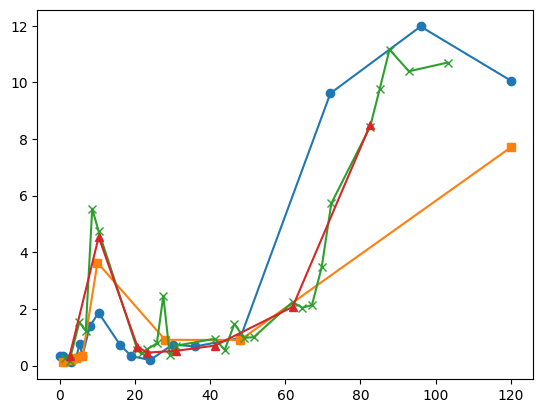

In [4]:
ds = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc")
gene = ds.ensembl_gene_id[20]
ds1 = ds.sel(source="White").tpm.sel(ensembl_gene_id=gene).dropna(dim="time", how="all", )
ds2 = ds.sel(source="Pauli").tpm.sel(ensembl_gene_id=gene).dropna(dim="time", how="all", )
ds3 = ds.sel(source="BK").tpm.sel(ensembl_gene_id=gene).dropna(dim="time", how="all", )
ds4 = ds.sel(source="JN").tpm.sel(ensembl_gene_id=gene).dropna(dim="time", how="all", )

ds0= ds2
# common grid spanning the overlapping time range
t_start = max(ds1.time.values[0], ds0.time.values[0])
t_end = min(ds1.time.values[-1], ds0.time.values[-1])
grid = np.linspace(t_start, t_end, num=200)

v1_interp = interpolate_to_grid(ds1.time.values, ds1.values, grid)
v2_interp = interpolate_to_grid(ds0.time.values, ds0.values, grid)

distance = dtw.distance(v1_interp, v2_interp)
print(distance)

plt.plot(ds1.time, ds1, "o-")
plt.plot(ds2.time, ds2, "s-")
plt.plot(ds3.time, ds3, "x-")
plt.plot(ds4.time, ds4, "^-")
plt.show()

### 24 hpf

In [ ]:
ds24 = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(time=slice(0, 24))
ds24["tpm"] = np.log2(ds24.tpm + 1)

ds_clean24 = ds24.dropna(dim="time", how="all", subset=["tpm"])
mask = (ds_clean24.tpm.max(dim="time", skipna=True) >= 1).any(dim="source")
ds_filtered24 = ds_clean24.sel(ensembl_gene_id=mask)

traj24 = xr.load_dataarray("results/all_gene_trajectories_24.nc")
gof24 = pd.read_csv("results/gof_trajectories_24.csv")
gof24.groupby("source").sum("accepted") / gof24.groupby("source").count().drop(columns="ensembl_gene_id")

,nrmse,accepted
source,,
BK,0.260398,0.487624
JN,0.333862,0.511715
Pauli,0.527503,0.306701
White,0.208357,0.640836


Mean NRMSE:  source
BK       0.260398
JN       0.333862
Pauli    0.527503
White    0.208357
Name: nrmse, dtype: float64 



<Axes: title={'center': 'Accepted NRMSE by Source (24 hpf)'}, ylabel='Source'>

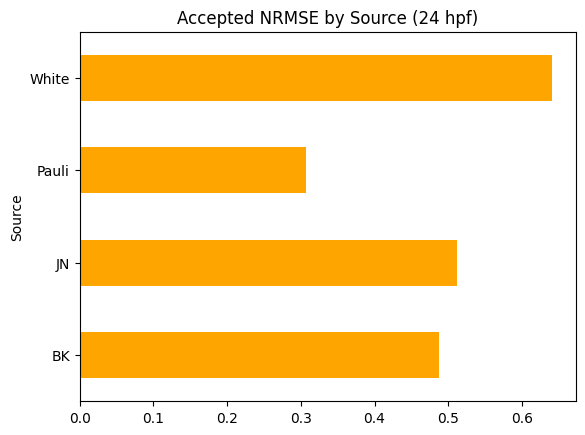

In [6]:
print("Mean NRMSE: ", gof24.groupby("source").nrmse.mean(), "\n")
gof24.groupby("source").nrmse.mean().plot.barh(color="orange", ylabel="Source", y="Mean NRMSE", title="Mean NRMSE by Source (24)")
plt.close()

(gof24.groupby("source").accepted.sum() / gof24.groupby("source").count()["ensembl_gene_id"]).plot.barh(color="orange", ylabel="Source", y="% accepted", title="Accepted NRMSE by Source (24 hpf)")

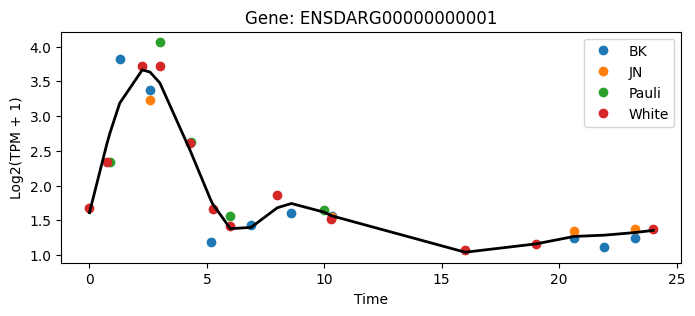

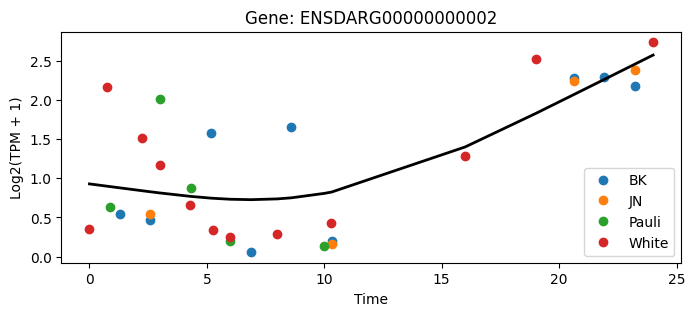

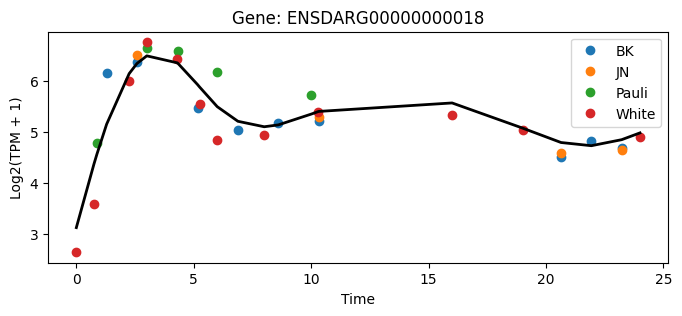

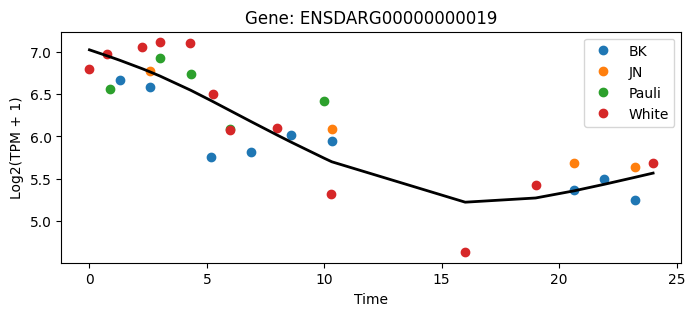

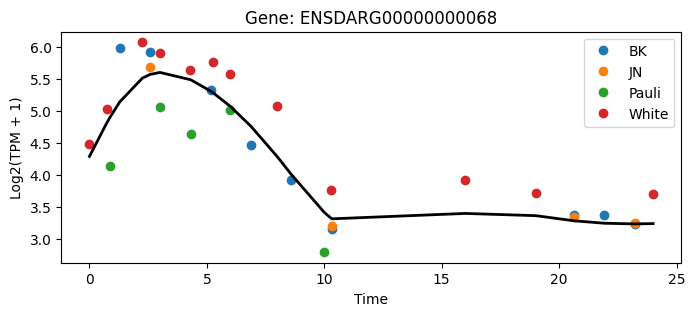

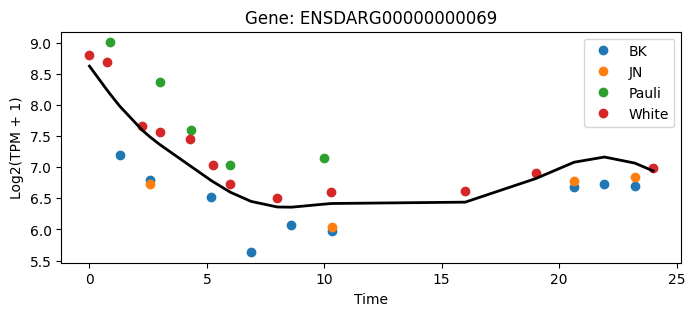

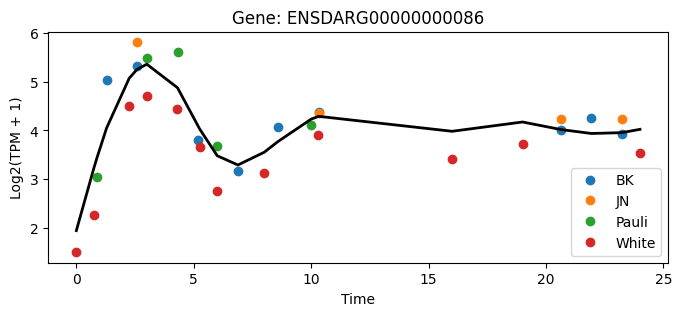

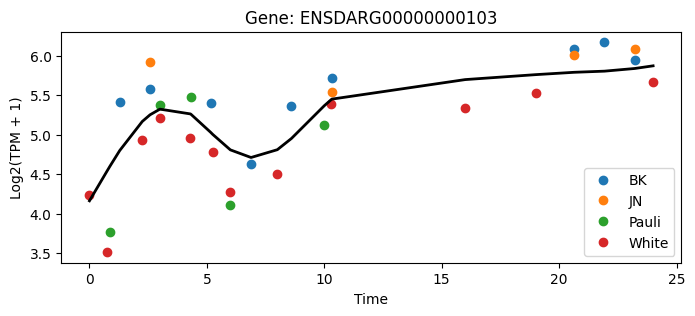

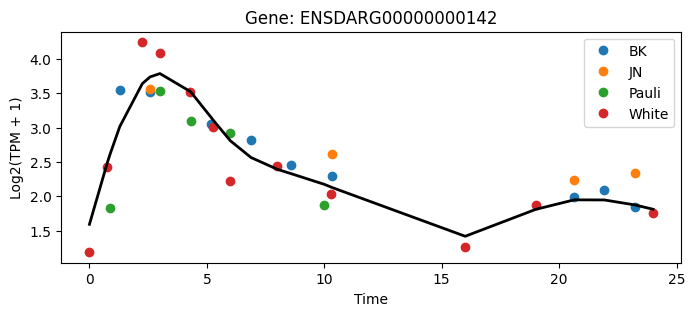

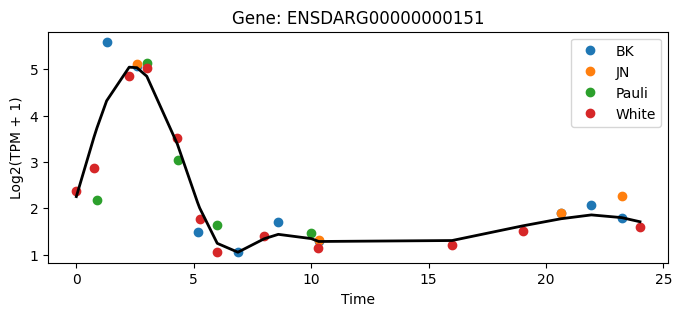

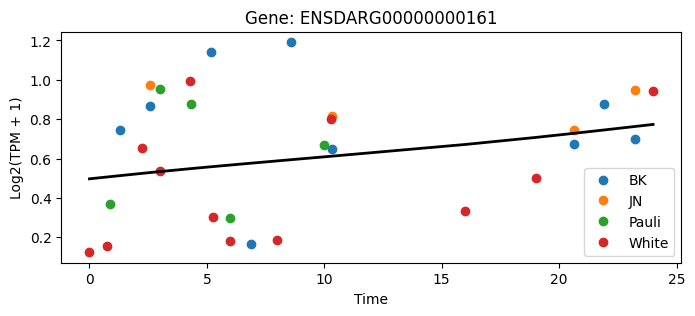

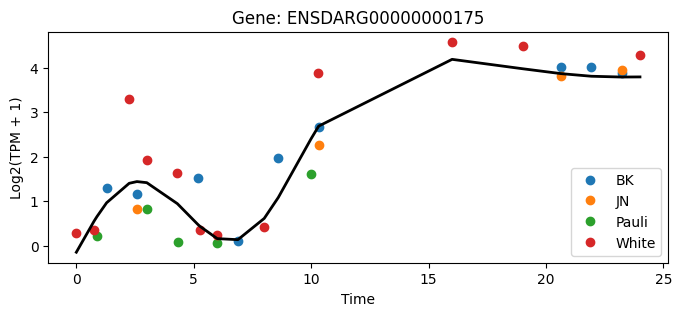

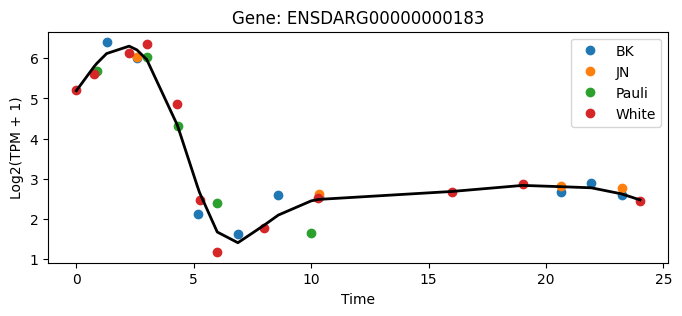

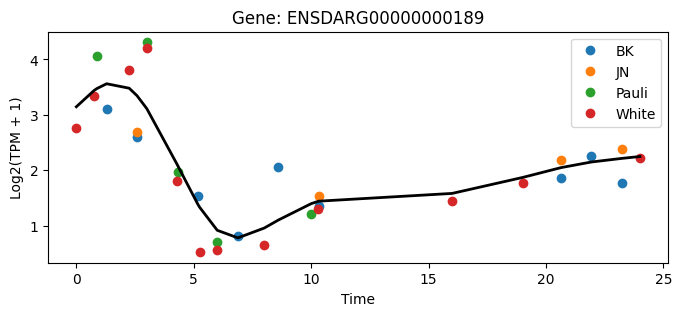

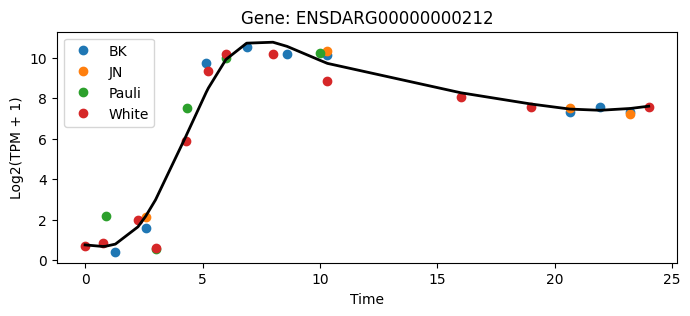

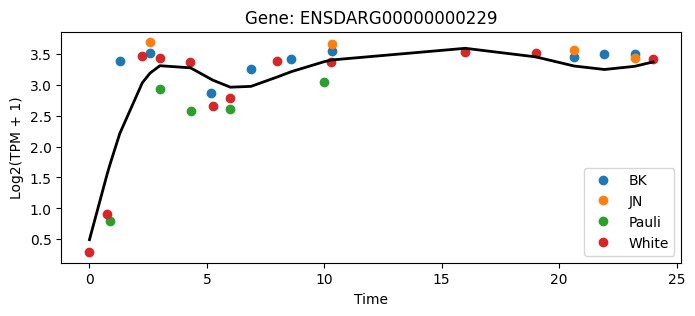

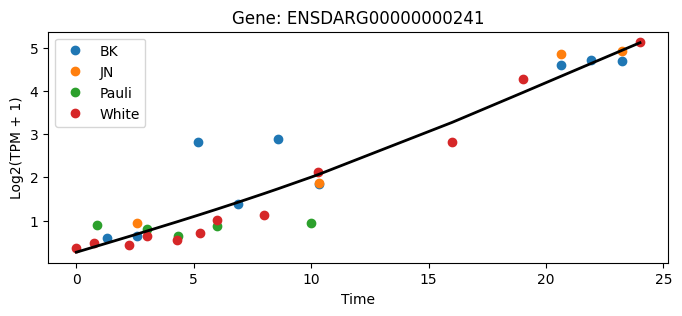

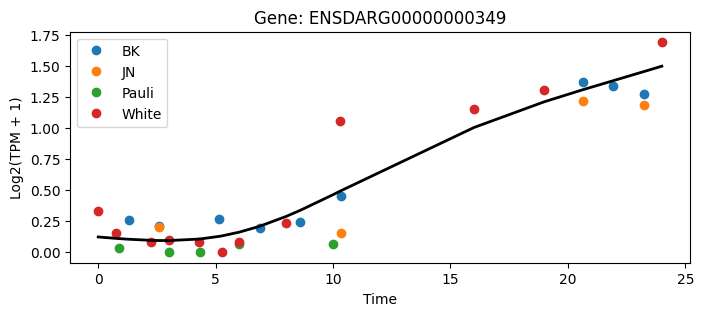

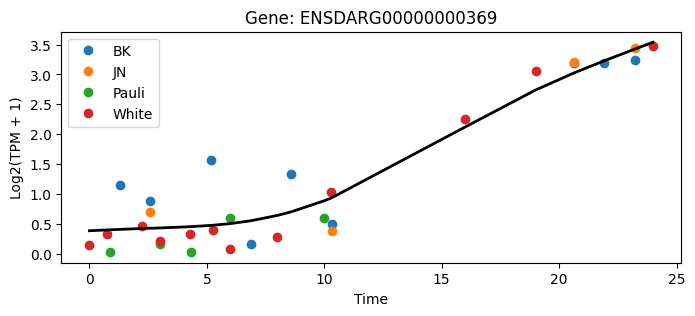

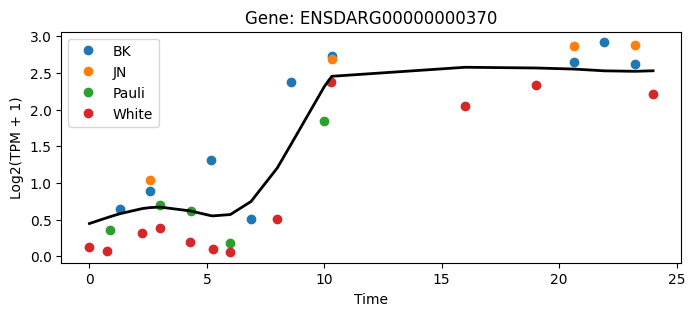

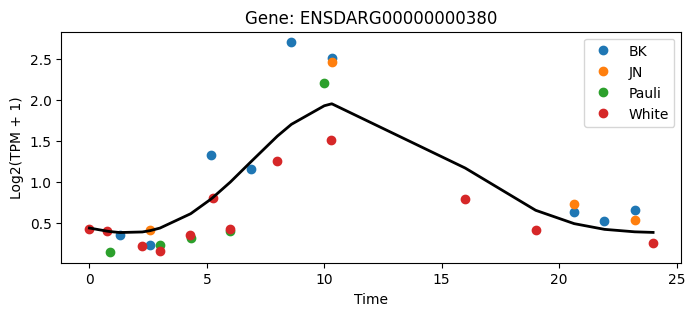

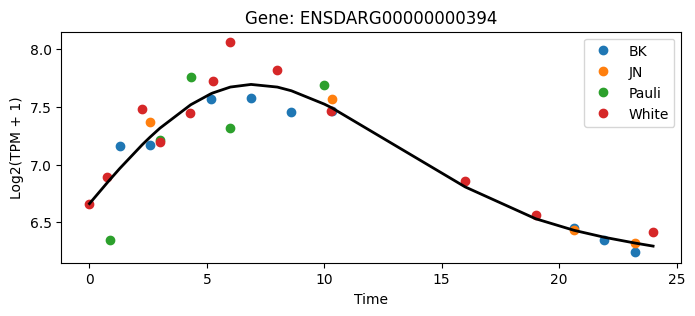

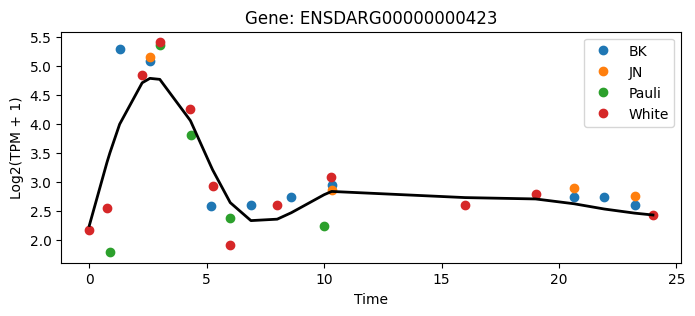

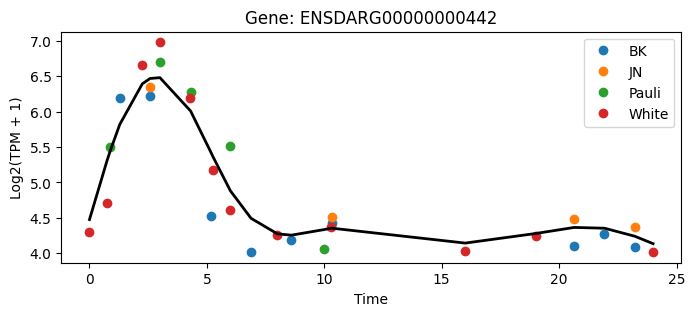

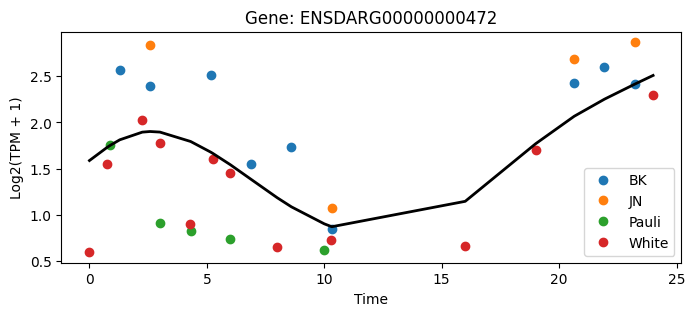

In [7]:
sc = ds24.source.values

for g in traj24.ensembl_gene_id.values[0:25]:
    y_true = ds_filtered24.sel(ensembl_gene_id=g, drop=True).tpm
    y_pred = traj24.sel(ensembl_gene_id=g, drop=True)
    plt.figure(figsize=(8,3))
    plt.plot(ds_filtered24.time, y_true,  marker="o", ls="", label=sc)
    plt.plot(ds_filtered24.time, y_pred, "k", lw=2)
    plt.title(f"Gene: {g}")
    plt.xlabel("Time")
    plt.ylabel("Log2(TPM + 1)")
    plt.legend()
    plt.show()

## 16 hpf

In [6]:
ds16 = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc").sel(time=slice(0, 16))
ds16["tpm"] = np.log2(ds16.tpm + 1)

ds_clean16 = ds16.dropna(dim="time", how="all", subset=["tpm"])
mask = (ds_clean16.tpm.max(dim="time", skipna=True) >= 1).any(dim="source")
ds_filtered16 = ds_clean16.sel(ensembl_gene_id=mask)

traj16 = xr.load_dataarray("results/all_gene_trajectories_16.nc")
gof16 = pd.read_csv("results/gof_trajectories_16.csv")
gof16.groupby("source").sum("accepted") / gof16.groupby("source").count().drop(columns="ensembl_gene_id")

,nrmse,accepted
source,,
BK,0.310037,0.358332
JN,5.513748,0.388979
Pauli,0.479880,0.326319
White,0.248529,0.584642


<Axes: xlabel='nrmse', ylabel='Density'>

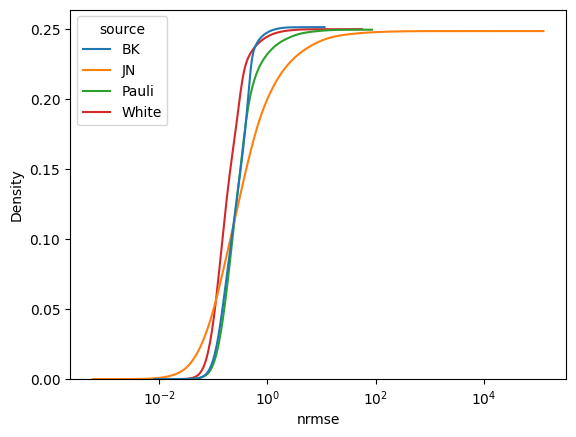

In [7]:
sns.kdeplot(gof16, x="nrmse", hue="source", log_scale=True, cumulative=True)

Mean NRMSE:  source
BK       0.310037
JN       5.513748
Pauli    0.479880
White    0.248529
Name: nrmse, dtype: float64 



<Axes: title={'center': 'Accepted NRMSE by Source (16 hpf)'}, ylabel='Source'>

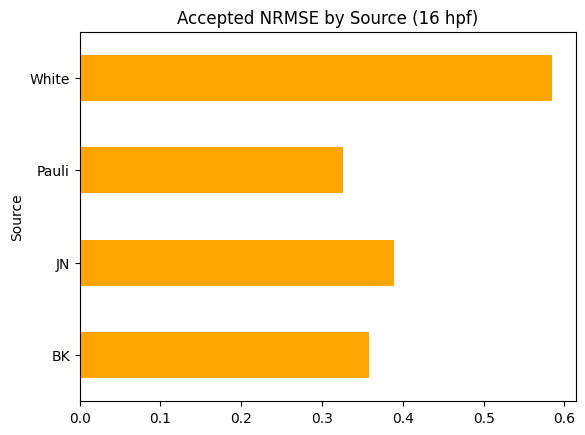

In [8]:
print("Mean NRMSE: ", gof16.groupby("source").nrmse.mean(), "\n")
gof16.groupby("source").nrmse.mean().plot.barh(color="orange", ylabel="Source", y="Mean NRMSE", title="Mean NRMSE by Source (24)")
plt.close()

(gof16.groupby("source").accepted.sum() / gof16.groupby("source").count()["ensembl_gene_id"]).plot.barh(color="orange", ylabel="Source", y="% accepted", title="Accepted NRMSE by Source (16 hpf)")

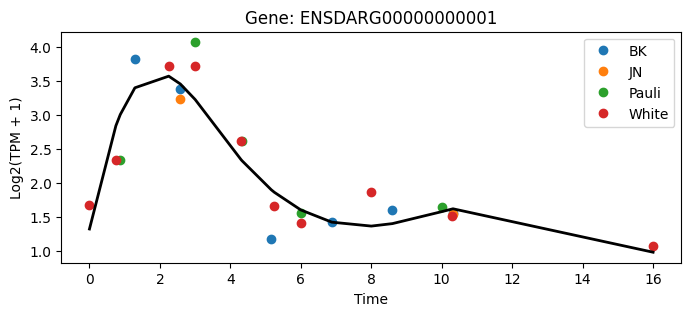

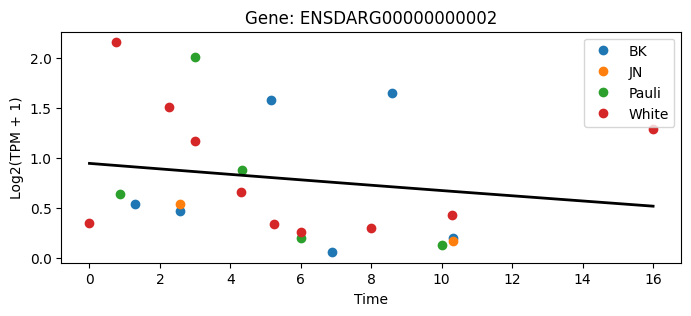

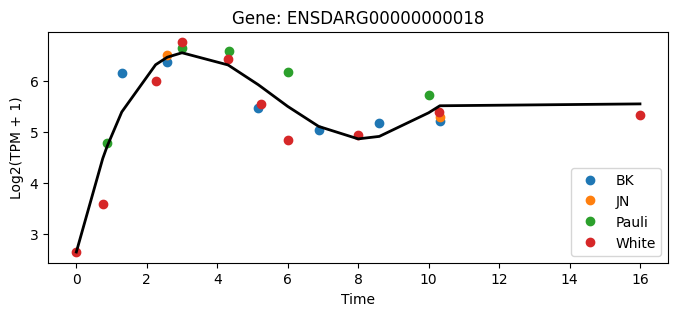

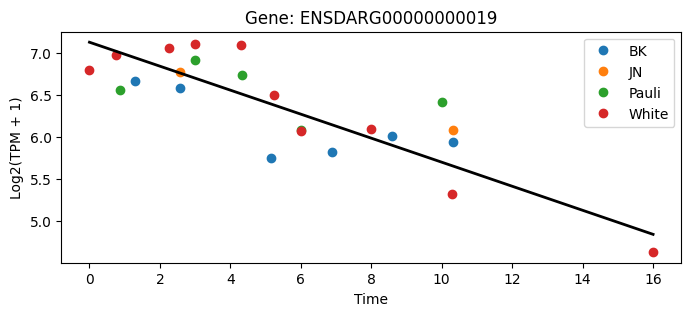

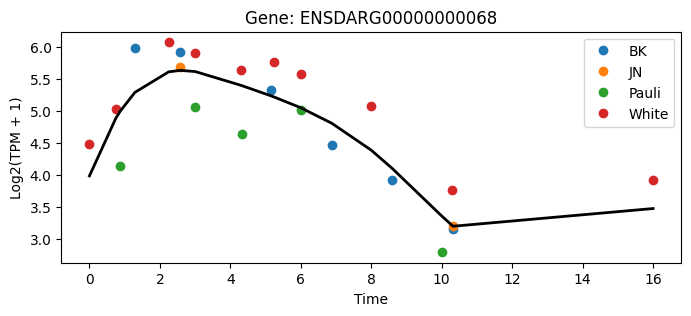

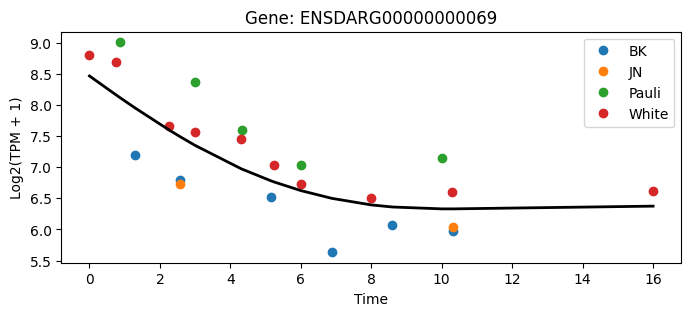

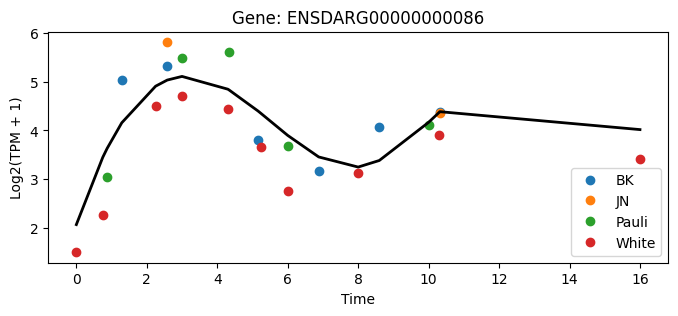

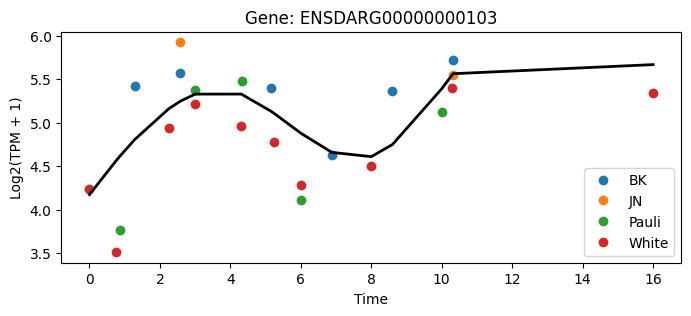

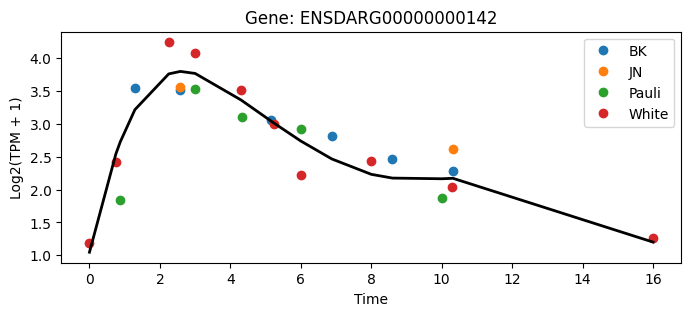

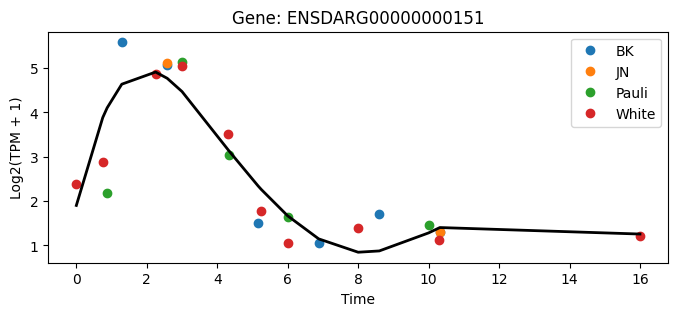

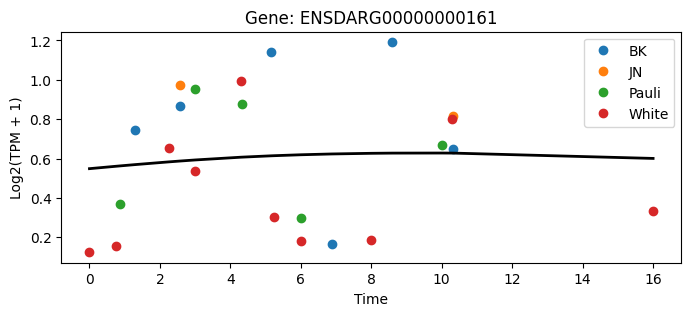

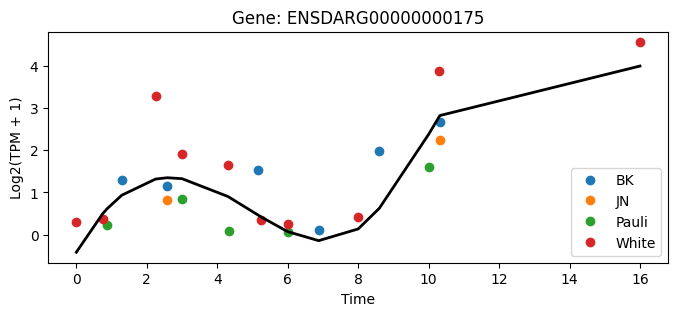

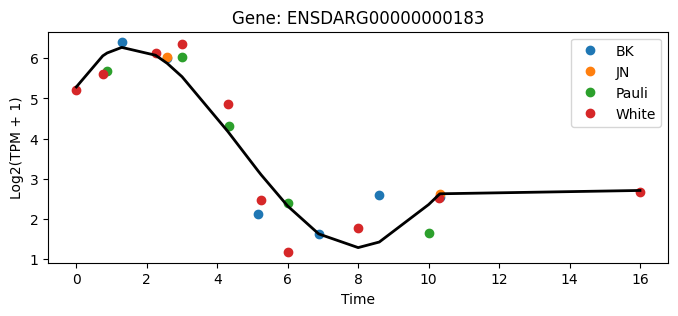

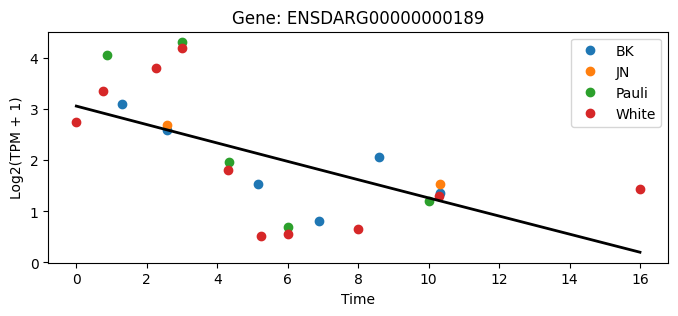

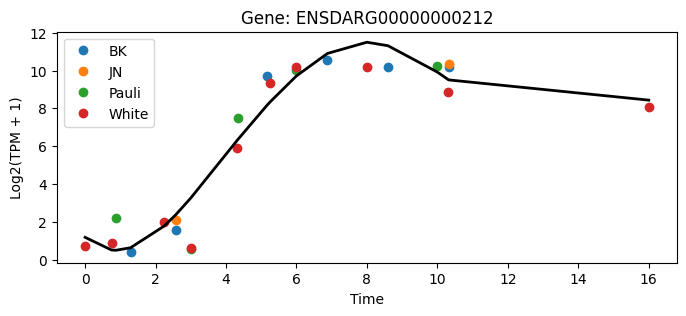

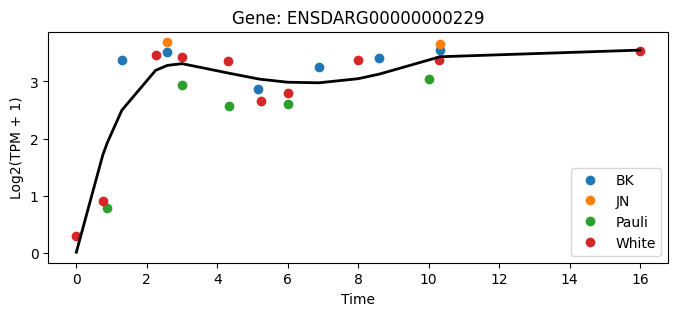

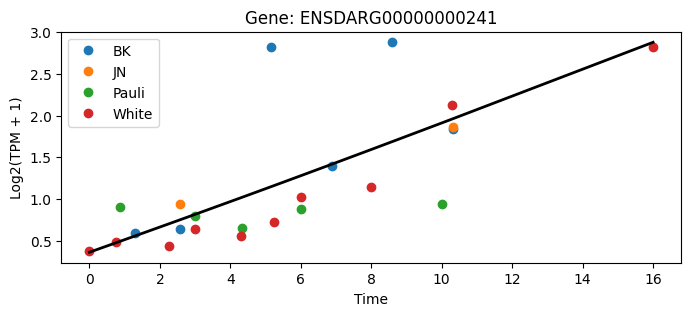

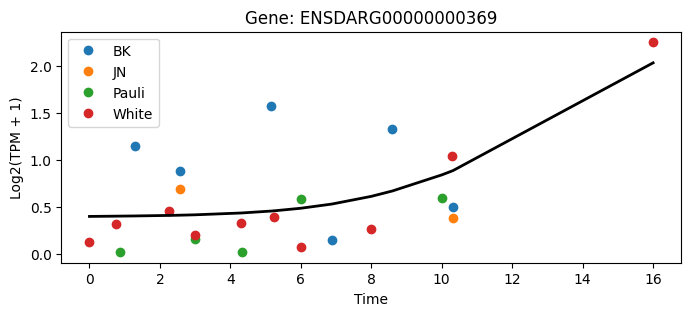

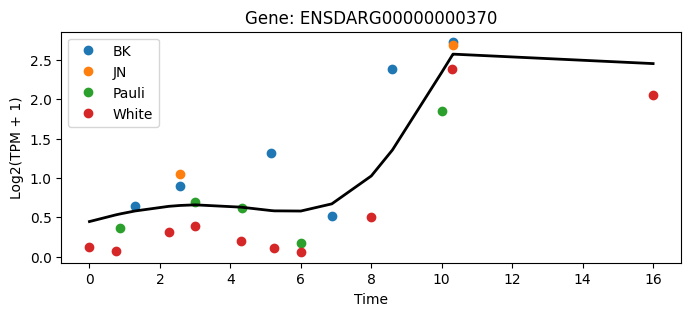

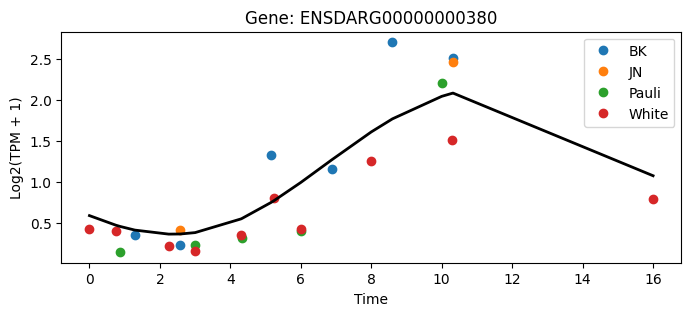

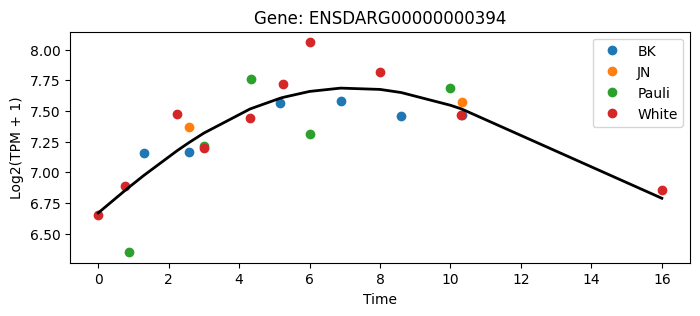

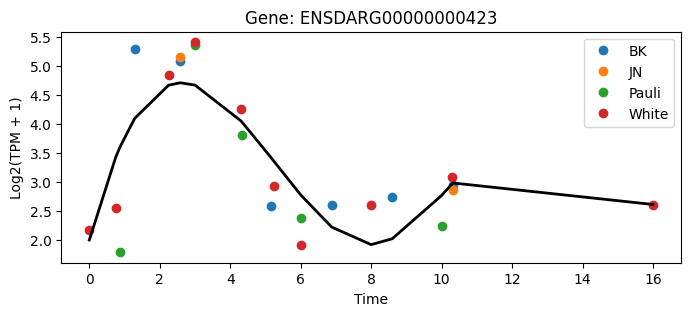

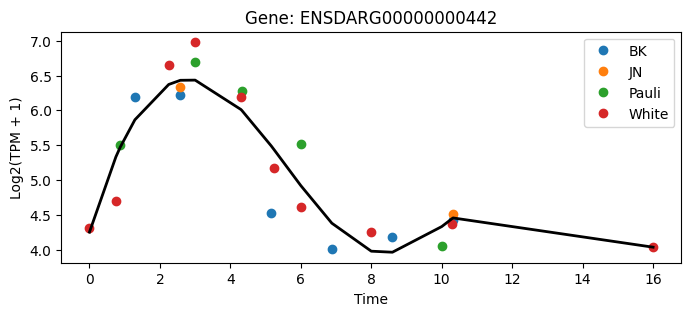

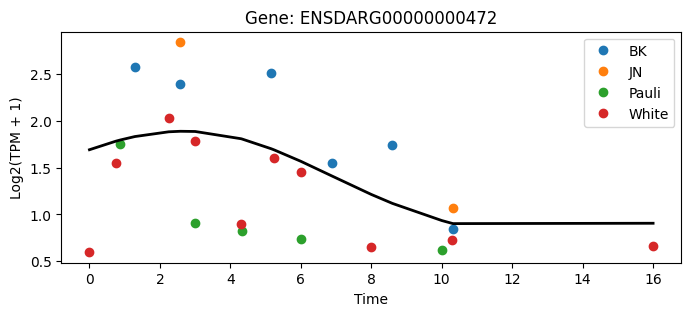

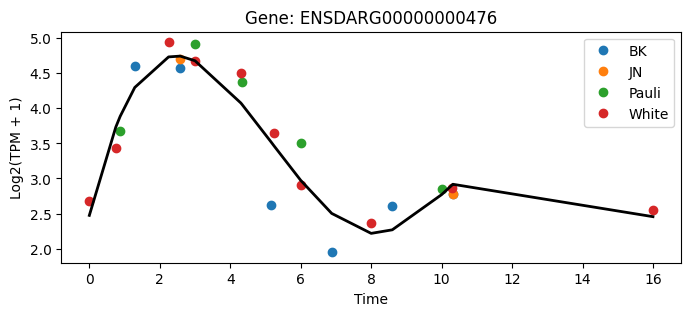

In [9]:
sc = ds16.source.values

for g in traj16.ensembl_gene_id.values[0:25]:
    y_true = ds_filtered16.sel(ensembl_gene_id=g, drop=True).tpm
    y_pred = traj16.sel(ensembl_gene_id=g, drop=True)
    plt.figure(figsize=(8,3))
    plt.plot(ds_filtered16.time, y_true,  marker="o", ls="", label=sc)
    plt.plot(ds_filtered16.time, y_pred, "k", lw=2)
    plt.title(f"Gene: {g}")
    plt.xlabel("Time")
    plt.ylabel("Log2(TPM + 1)")
    plt.legend()
    plt.show()

Kept 23428 / 23428 genes after dynamic range filter (>= 1.0 log2 units)


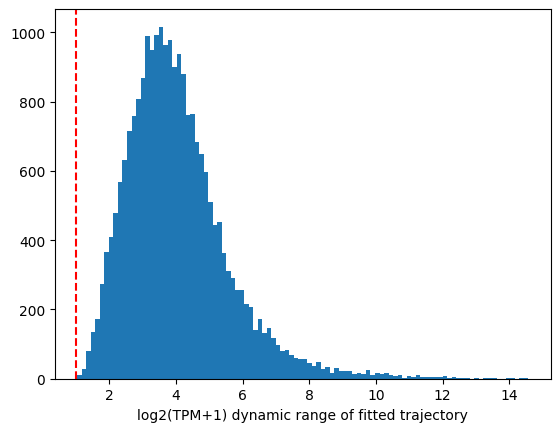

In [10]:
ds = xr.load_dataset("../data/genes_tpms_white_pauli_JN_BK_mean.nc")
ds_clean = ds.dropna(dim="time", how="all", subset=["tpm"])
mask = ((ds_clean.tpm.max(dim="time", skipna=True) >= 1) & (ds_clean.tpm.std(("time")) > 0.05)).all(dim="source")
ds_clean = ds_clean.sel(ensembl_gene_id=mask)
ds_clean["tpm"] = np.log2(ds_clean.tpm + 1)

# Compute dynamic range of fitted trajectory in log2(TPM+1) space, before min-max scaling
dyn_range = ds_clean.tpm.max(dim=("time", "source")) - ds_clean.tpm.min(dim=("time", "source"))

MIN_LOG2_RANGE = 1.0  # e.g. >= 2-fold change; tune based on inspection below
range_mask = dyn_range >= MIN_LOG2_RANGE
trajectories_filtered = ds_clean.sel(ensembl_gene_id=range_mask)

print(f"Kept {range_mask.sum().item()} / {ds_clean.sizes['ensembl_gene_id']} genes "
      f"after dynamic range filter (>= {MIN_LOG2_RANGE} log2 units)")

import matplotlib.pyplot as plt
dyn_range.plot.hist(bins=100)
plt.axvline(MIN_LOG2_RANGE, color="red", linestyle="--")
plt.xlabel("log2(TPM+1) dynamic range of fitted trajectory")
plt.show()

### heatmap

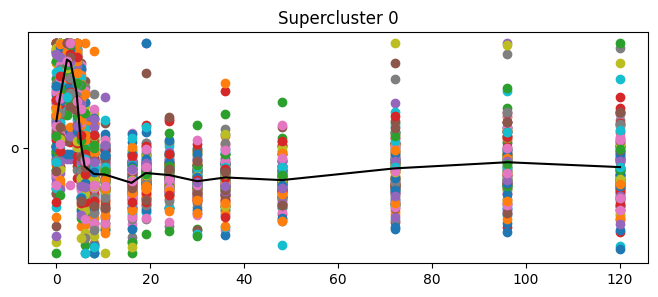

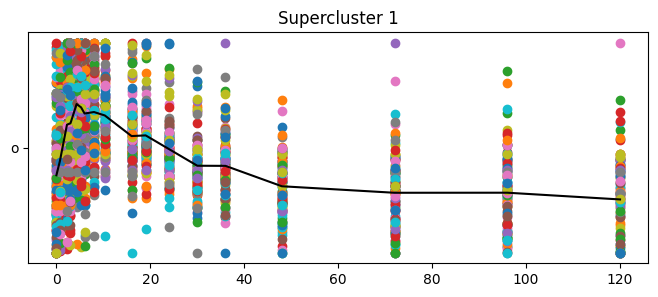

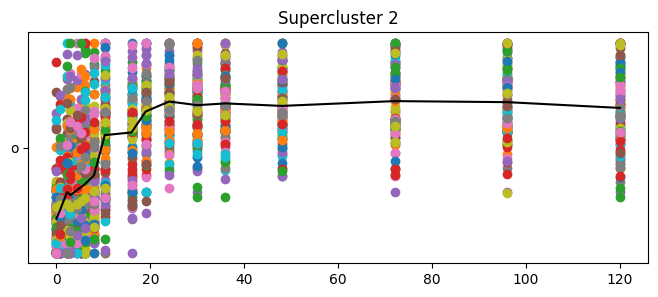

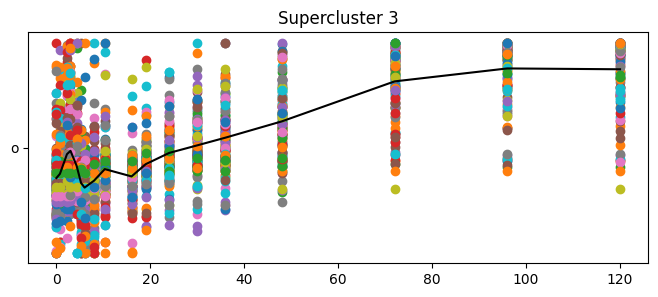

In [80]:
ann = xr.load_dataset("results/all_gene_cluster_annotation_minmax.nc").sel(source="White", drop=True)
ann = ann.dropna(dim="time", how="all", subset=["tpm"])
ann = ann.sel(ensembl_gene_id=ann.ensembl_gene_id.values[0:500])

ann["tpm"] = np.log2(ann.tpm+1)

for s in np.unique(ann.supercluster.values):
    plt.figure(figsize=(8, 3))
    X = ann.sel(ensembl_gene_id=ann.supercluster == s).tpm
    X_z = (X - X.mean("time")) / abs(X- X.mean("time")).max("time")

    if "source" in X_z.dims:
        tpm = tpm.mean(dim="source", skipna=True)   # or .sel(source="...") for one source

    plt.plot(X.time, X_z, "o")
    plt.plot(X.time, X_z.mean(dim="ensembl_gene_id"), "k", "o")
    plt.title(f"Supercluster {s}")
    plt.show()

### Sankey diagramm

In [61]:
from pySankey.sankey import sankey
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def cluster_agreement(ds1, ds2, algo1, algo2):

   df1 = pd.DataFrame({"ensembl_gene_id": ds1.ensembl_gene_id.values, "cluster":ds1.cluster_label.values})
   df2 = pd.DataFrame({"ensembl_gene_id": ds2.ensembl_gene_id.values, "cluster2":ds2.cluster.values})

   dup1 = df1["ensembl_gene_id"].duplicated().sum()
   dup2 = df2["ensembl_gene_id"].duplicated().sum()
   if dup1 or dup2:
      print(f"Warning: {dup1} duplicate ids in ds1, {dup2} duplicate ids in ds2")

   df = df1.merge(df2, on="ensembl_gene_id", how="inner", validate="one_to_one")

   df["agreement"] = (df["cluster"] == df["cluster2"])
   df = df.dropna(subset=["cluster", "cluster2"])
   df = df.sort_values(["cluster", "cluster2"], ascending=False)

   sankey(left=df["cluster"], right=df["cluster2"], 
         aspect=20, fontsize=12,
         figure_name=f"figs/cluster_agreement_{algo1}_{algo2}")

   # Get current figure
   fig = plt.gcf()
   fig.set_size_inches(6, 6)
   fig.set_facecolor("w")
   plt.title(f"Cluster changes ({algo1} → {algo2})")
   fig.savefig(f"figs/cluster_agreement_{algo1}_{algo2}.png", bbox_inches="tight", dpi=300)

   agree = df["agreement"].sum() / len(df) * 100
   print(f"Cluster agreement: {agree:.2f} %")

   return df

Cluster agreement: 69.13 %


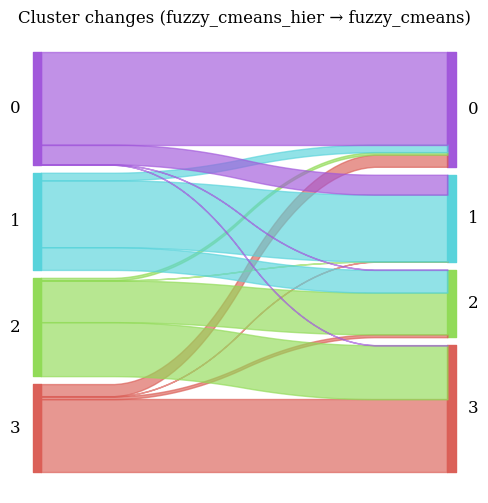

In [62]:
algo1 = "fuzzy_cmeans_hier"
ds1 = xr.load_dataset("results/all_superclusters_labels.nc")

algo2 = "fuzzy_cmeans"
ds2 = xr.load_dataset("results/fuzzy_c-means_clustered_ds_White et al..nc")

# algo2 = "ts_k-means"
# ds2 = xr.load_dataset("results/ts_k-means_euclidean_clustered_ds_White et al..nc")

#algo2 = "k-medoids"
#ds2 = xr.load_dataset("results/k_medoids_clustered_ds_White et al..nc")

df = cluster_agreement(ds1, ds2, algo1, algo2)